<a href="https://colab.research.google.com/github/LGsekara1/Glove_Rejection_and_Inspection_Process_-GRIP-/blob/main/leyolo_embedded.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Embedded Object Detection: LeYOLO vs YOLO Family
### Based on: *LeYOLO — New Embedded Architecture for Object Detection* (arXiv:2406.14239)

This notebook reproduces the **Section IV comparison** from the LeYOLO paper and extends it with:
- FLOP-efficiency scoring (mAP / GFLOPs)
- Embedded suitability tiers (MCU / Edge SBC / Mobile GPU)
- Hardware specification calculator for your target FPS and mAP
- Pareto-front analysis (best accuracy per compute budget)

**Paper key claims:**
- LeYOLO-Small: 38.2 mAP @ 4.51 GFLOPs (42% fewer FLOPs than YOLOv9-Tiny at same accuracy)
- LeYOLO-Nano: 25.2 mAP @ 0.66 GFLOPs (sub-1 GFLOP region, ideal for MCUs)
- Uses inverted bottleneck + FPAN neck + DNiN head
- Benchmarked on STM32MP257FAI3 and STM32N6570-DK

**Note on FLOP convention:** The paper defines 1 FLOP ≈ 2 MACC. Many papers report MACs as FLOPs — all values here follow the paper's convention.

## Cell 1 — Install & Imports

In [1]:
import subprocess, sys
pkgs = ['torch','thop','tabulate','pandas','matplotlib','seaborn','numpy','scipy']
for p in pkgs:
    subprocess.check_call([sys.executable,'-m','pip','install',p,'-q'])
print('Ready.')

Ready.


## Cell 2 — Paper Data Table (Section IV)

All values sourced from Table 3 and surrounding comparison in arXiv:2406.14239v2.
- GFLOPs as defined by paper (1 FLOP ~ 2 MACC)
- mAP@COCO val (IoU=0.5)
- Params in millions
- Input resolution in pixels

In [2]:
import pandas as pd
import numpy as np

# ─── Paper comparison table (Section IV, arXiv:2406.14239v2) ─────────────────
# Columns: Model, GFLOPs, Params_M, mAP_50, Input, Family, Embedded_Class
# Embedded_Class: 'MCU' (<1 GFLOP), 'EdgeSBC' (1-10 GFLOP), 'MobileGPU' (10-50), 'GPU' (>50)
data = [
    # ── LeYOLO family (paper's proposed models) ──────────────────────────────
    ('LeYOLO-Nano',         0.66,  0.6,  25.2, 320, 'LeYOLO', 'MCU'),
    ('LeYOLO-Small-320',    1.47,  1.2,  31.3, 320, 'LeYOLO', 'EdgeSBC'),
    ('LeYOLO-Medium-320',   2.53,  1.8,  35.2, 320, 'LeYOLO', 'EdgeSBC'),
    ('LeYOLO-Small',        4.51,  2.1,  38.2, 640, 'LeYOLO', 'EdgeSBC'),
    ('LeYOLO-Medium',       5.80,  3.4,  39.3, 640, 'LeYOLO', 'EdgeSBC'),
    ('LeYOLO-Large',        8.40,  5.0,  41.0, 640, 'LeYOLO', 'EdgeSBC'),
    # ── LeNeck + SoTA backbones (paper Table VII) ────────────────────────────
    ('MobileNetV3+LeNeck',  0.98,  1.8,  26.5, 320, 'LeNeck', 'MCU'),
    ('MobileNetV2+LeNeck',  1.20,  2.0,  28.0, 320, 'LeNeck', 'EdgeSBC'),
    ('EfficientNet+LeNeck', 2.10,  2.5,  32.0, 320, 'LeNeck', 'EdgeSBC'),
    # ── SSDLite baselines (paper comparison) ─────────────────────────────────
    ('SSDLite-MobileNetV2', 0.80,  3.4,  22.1, 320, 'SSDLite','MCU'),
    ('SSDLite-MobileNetV3', 0.62,  2.9,  22.0, 320, 'SSDLite','MCU'),
    # ── YOLO Tiny/Nano mainline (paper Table III comparisons) ────────────────
    ('YOLOv5-Nano',         4.50,  1.9,  28.0, 640, 'YOLOv5', 'EdgeSBC'),
    ('YOLOv5-Small',       15.80,  7.2,  37.4, 640, 'YOLOv5', 'MobileGPU'),
    ('YOLOv6-Nano',         4.70,  4.7,  35.0, 640, 'YOLOv6', 'EdgeSBC'),
    ('YOLOv6-Small',       25.00, 18.5,  43.1, 640, 'YOLOv6', 'MobileGPU'),
    ('YOLOv8-Nano',         8.70,  3.2,  37.3, 640, 'YOLOv8', 'EdgeSBC'),
    ('YOLOv8-Small',       28.60, 11.2,  44.9, 640, 'YOLOv8', 'MobileGPU'),
    ('YOLOv9-Tiny',         7.80,  2.0,  38.3, 640, 'YOLOv9', 'EdgeSBC'),
    ('YOLOv9-Small',       26.70, 10.1,  46.7, 640, 'YOLOv9', 'MobileGPU'),
    ('YOLOv10-Nano',        6.70,  2.3,  38.5, 640, 'YOLOv10','EdgeSBC'),
    ('YOLOv10-Small',      21.60,  7.2,  46.3, 640, 'YOLOv10','MobileGPU'),
    # ── NanoDet (micro detector) ─────────────────────────────────────────────
    ('NanoDet-Plus-m',      0.90,  0.9,  34.5, 320, 'NanoDet','MCU'),
    ('NanoDet-Plus-m-1.5x', 2.30,  2.4,  38.8, 320, 'NanoDet','EdgeSBC'),
    # ── YOLO mainline large (for reference) ──────────────────────────────────
    ('YOLOv8-Large',      165.20, 43.7,  52.9, 640, 'YOLOv8', 'GPU'),
    ('YOLOv9-C',          102.10, 25.3,  53.0, 640, 'YOLOv9', 'GPU'),
]

df = pd.DataFrame(data, columns=['Model','GFLOPs','Params_M','mAP50','Input','Family','EmbeddedClass'])
df['FLOP_Efficiency'] = (df['mAP50'] / df['GFLOPs']).round(3)  # mAP points per GFLOP
df['Param_Efficiency'] = (df['mAP50'] / df['Params_M']).round(3) # mAP per M params

# Estimated min RAM for deployment (model weights FP32 + ~3x activation overhead)
df['MinRAM_MB'] = ((df['Params_M'] * 4 * 4)).round(1)  # 4 bytes * 4x overhead

print(df[['Model','GFLOPs','Params_M','mAP50','FLOP_Efficiency','EmbeddedClass']].to_string(index=False))


              Model  GFLOPs  Params_M  mAP50  FLOP_Efficiency EmbeddedClass
        LeYOLO-Nano    0.66       0.6   25.2           38.182           MCU
   LeYOLO-Small-320    1.47       1.2   31.3           21.293       EdgeSBC
  LeYOLO-Medium-320    2.53       1.8   35.2           13.913       EdgeSBC
       LeYOLO-Small    4.51       2.1   38.2            8.470       EdgeSBC
      LeYOLO-Medium    5.80       3.4   39.3            6.776       EdgeSBC
       LeYOLO-Large    8.40       5.0   41.0            4.881       EdgeSBC
 MobileNetV3+LeNeck    0.98       1.8   26.5           27.041           MCU
 MobileNetV2+LeNeck    1.20       2.0   28.0           23.333       EdgeSBC
EfficientNet+LeNeck    2.10       2.5   32.0           15.238       EdgeSBC
SSDLite-MobileNetV2    0.80       3.4   22.1           27.625           MCU
SSDLite-MobileNetV3    0.62       2.9   22.0           35.484           MCU
        YOLOv5-Nano    4.50       1.9   28.0            6.222       EdgeSBC
       YOLOv

## Cell 3 — Visualisation: FLOP vs mAP (Pareto Analysis)

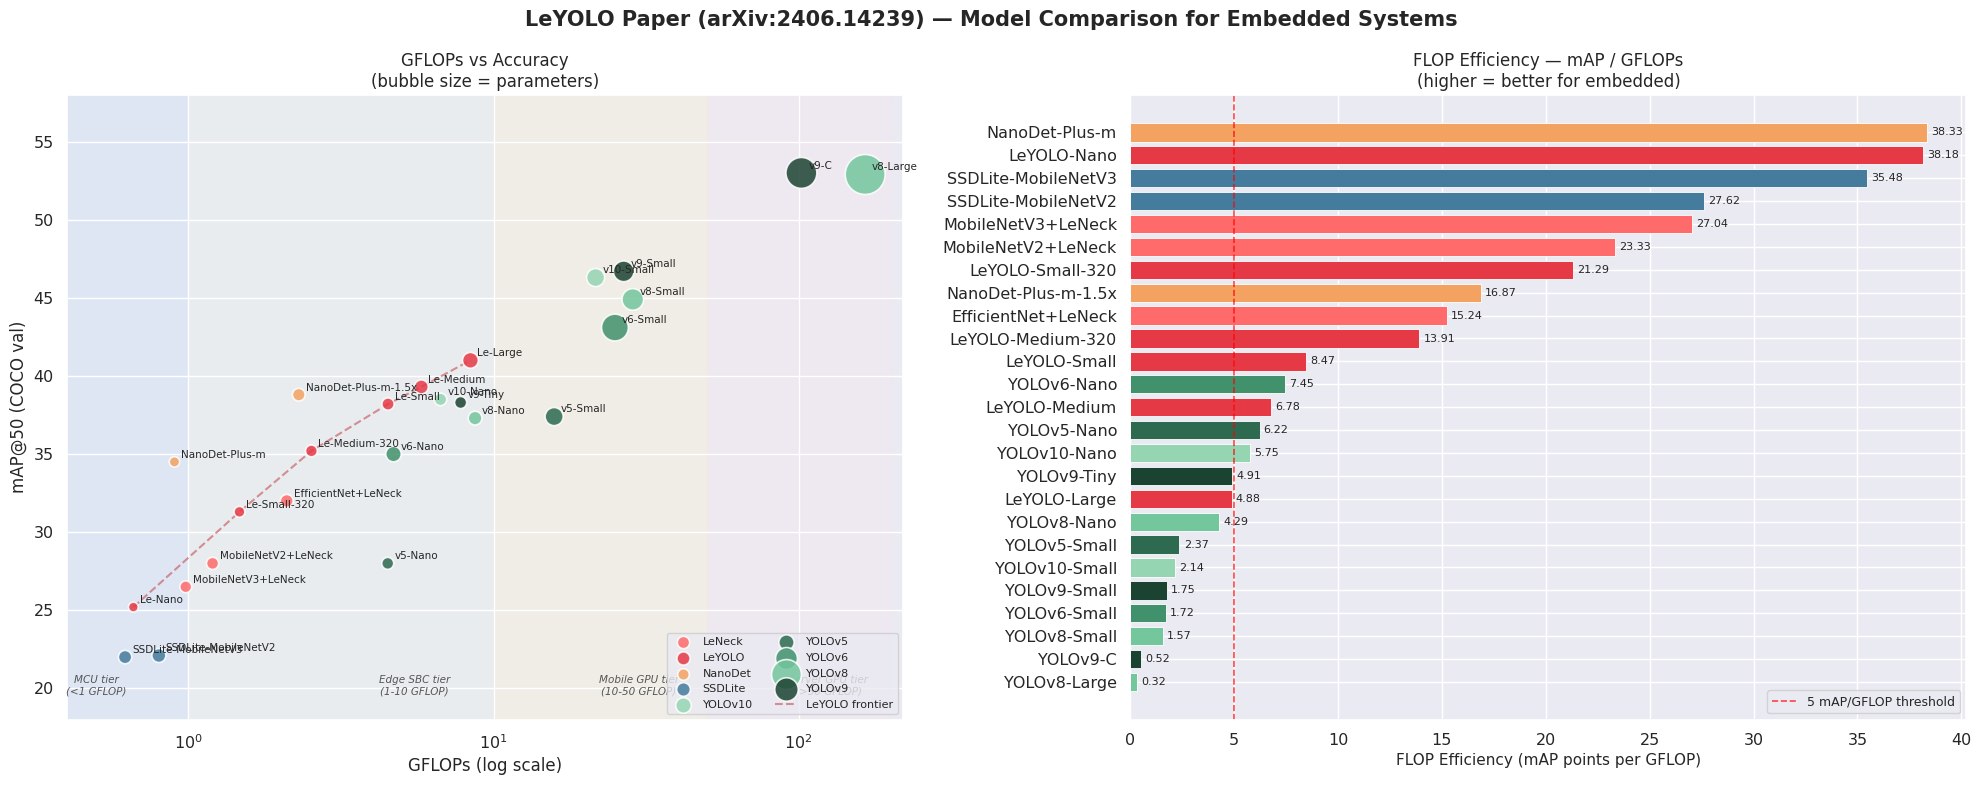

Saved: leyolo_comparison.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='darkgrid', font_scale=1.05)

FAMILY_COLORS = {
    'LeYOLO':  '#e63946',
    'LeNeck':  '#ff6b6b',
    'SSDLite': '#457b9d',
    'YOLOv5':  '#2d6a4f',
    'YOLOv6':  '#40916c',
    'YOLOv8':  '#74c69d',
    'YOLOv9':  '#1b4332',
    'YOLOv10': '#95d5b2',
    'NanoDet': '#f4a261',
}

TIER_BANDS = [
    (0,    1,    '#bbdefb', 'MCU tier\n(<1 GFLOP)'),
    (1,   10,    '#e8f5e9', 'Edge SBC tier\n(1-10 GFLOP)'),
    (10,  50,    '#fff9c4', 'Mobile GPU tier\n(10-50 GFLOP)'),
    (50, 200,    '#fce4ec', 'Server GPU tier\n(>50 GFLOP)'),
]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('LeYOLO Paper (arXiv:2406.14239) — Model Comparison for Embedded Systems',
             fontsize=15, fontweight='bold')

# ── Plot 1: GFLOPs vs mAP (main comparison) ───────────────────────────────
ax = axes[0]
for lo, hi, color, label in TIER_BANDS:
    ax.axvspan(lo, hi, alpha=0.25, color=color, zorder=0)
    ax.text((lo+hi)/2, 19.5, label, ha='center', va='bottom', fontsize=7.5,
            color='#555', style='italic')

# Plot each family
for family, grp in df.groupby('Family'):
    ax.scatter(grp['GFLOPs'], grp['mAP50'],
               s=grp['Params_M']*18+40, color=FAMILY_COLORS.get(family,'grey'),
               alpha=0.85, edgecolors='white', linewidths=1.2,
               label=family, zorder=4)
    for _, row in grp.iterrows():
        ax.annotate(row['Model'].replace('LeYOLO-','Le-').replace('YOLOv','v'),
                    (row['GFLOPs'], row['mAP50']),
                    xytext=(5, 3), textcoords='offset points', fontsize=7.5, zorder=5)

# Pareto frontier (LeYOLO only for clarity)
ley = df[df['Family']=='LeYOLO'].sort_values('GFLOPs')
ax.plot(ley['GFLOPs'], ley['mAP50'], 'r--', lw=1.5, alpha=0.6, label='LeYOLO frontier')

ax.set_xscale('log')
ax.set_xlabel('GFLOPs (log scale)', fontsize=12)
ax.set_ylabel('mAP@50 (COCO val)', fontsize=12)
ax.set_title('GFLOPs vs Accuracy\n(bubble size = parameters)', fontsize=12)
ax.set_xlim(0.4, 220)
ax.set_ylim(18, 58)
ax.legend(loc='lower right', fontsize=8, ncol=2)

# ── Plot 2: FLOP Efficiency (mAP/GFLOP) ──────────────────────────────────
ax2 = axes[1]
df_sorted = df.sort_values('FLOP_Efficiency')
colors_bar = [FAMILY_COLORS.get(f,'grey') for f in df_sorted['Family']]
bars = ax2.barh(df_sorted['Model'], df_sorted['FLOP_Efficiency'],
                color=colors_bar, edgecolor='white', linewidth=0.6)
ax2.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
ax2.set_xlabel('FLOP Efficiency (mAP points per GFLOP)', fontsize=11)
ax2.set_title('FLOP Efficiency — mAP / GFLOPs\n(higher = better for embedded)', fontsize=12)
ax2.axvline(x=5, color='red', ls='--', lw=1.2, alpha=0.7, label='5 mAP/GFLOP threshold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('leyolo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: leyolo_comparison.png')


## Cell 4 — Pareto Front & Embedded Tier Ranking

In [4]:
from tabulate import tabulate

def pareto_front(df, x_col, y_col):
    """Returns Pareto-optimal rows: lowest x for highest y (minimise FLOPs, maximise mAP)."""
    df_s = df.sort_values(x_col).reset_index(drop=True)
    pareto = []
    best_y = -np.inf
    for _, row in df_s.iterrows():
        if row[y_col] > best_y:
            best_y = row[y_col]
            pareto.append(row)
    return pd.DataFrame(pareto)

pf = pareto_front(df, 'GFLOPs', 'mAP50')
print('=== PARETO-OPTIMAL MODELS (best mAP at each compute budget) ===')
print(tabulate(pf[['Model','Family','GFLOPs','Params_M','mAP50','FLOP_Efficiency','EmbeddedClass']],
              headers='keys', tablefmt='fancy_grid', numalign='right', showindex=False))

print()
print('=== RANKING BY TIER ===')
for tier in ['MCU','EdgeSBC','MobileGPU','GPU']:
    sub = df[df['EmbeddedClass']==tier].sort_values('mAP50', ascending=False)
    if len(sub) == 0: continue
    print(f'\n--- {tier} Tier ---')
    print(tabulate(sub[['Model','GFLOPs','Params_M','mAP50','FLOP_Efficiency','MinRAM_MB']],
                  headers=['Model','GFLOPs','Params(M)','mAP50','mAP/GFLOP','Min RAM (MB)'],
                  tablefmt='grid', numalign='right', showindex=False))


=== PARETO-OPTIMAL MODELS (best mAP at each compute budget) ===
╒═════════════════════╤══════════╤══════════╤════════════╤═════════╤═══════════════════╤═════════════════╕
│ Model               │ Family   │   GFLOPs │   Params_M │   mAP50 │   FLOP_Efficiency │ EmbeddedClass   │
╞═════════════════════╪══════════╪══════════╪════════════╪═════════╪═══════════════════╪═════════════════╡
│ SSDLite-MobileNetV3 │ SSDLite  │     0.62 │        2.9 │      22 │            35.484 │ MCU             │
├─────────────────────┼──────────┼──────────┼────────────┼─────────┼───────────────────┼─────────────────┤
│ LeYOLO-Nano         │ LeYOLO   │     0.66 │        0.6 │    25.2 │            38.182 │ MCU             │
├─────────────────────┼──────────┼──────────┼────────────┼─────────┼───────────────────┼─────────────────┤
│ NanoDet-Plus-m      │ NanoDet  │      0.9 │        0.9 │    34.5 │            38.333 │ MCU             │
├─────────────────────┼──────────┼──────────┼────────────┼─────────┼────────────

## Cell 5 — Embedded Hardware Specification Calculator

Given your **target FPS** and **chosen model**, this calculator derives:
- Required **compute throughput** (GOPS)
- Minimum **RAM** (MB)
- Minimum **Flash / Storage** (MB)
- Suggested **hardware tier** and example chips

**Formula basis:**
```
Required GOPS = GFLOPs_per_frame x target_FPS
                -----------------------------------------
                  hardware_utilisation_factor (typ. 0.3)
```
The utilisation factor accounts for memory bandwidth limits, activation overhead,
and non-compute pipeline stages. 0.3 is conservative; optimised INT8 NPUs reach 0.5-0.7.

In [5]:
import math

# ─── Hardware reference table ─────────────────────────────────────────────────
# (Name, Peak GOPS FP32, Peak TOPS INT8, RAM_GB, typical_power_W, price_usd, tier)
HW_TABLE = [
    # MCU / ultra-low-power
    ('STM32H7 (MCU)',        0.856,  None,   0.001, 0.08,  3,    'MCU'),
    ('STM32MP257 (MPU+NPU)', 2.3,    4.6,    0.512, 0.5,   10,   'MCU'),
    ('STM32N6570 (NPU)',     0.6,   600.0,   1.0,   0.3,   15,   'MCU'),
    ('Arduino Nicla Vision', 0.08,   None,   0.001, 0.05,  50,   'MCU'),
    # Edge SBC (Single Board Computers)
    ('Raspberry Pi 4',       13.5,   None,   4.0,   3.0,   35,   'EdgeSBC'),
    ('Raspberry Pi 5',       27.0,   None,   8.0,   5.0,   60,   'EdgeSBC'),
    ('BeagleBone AI-64',     16.0,    8.0,   4.0,   5.0,   133,  'EdgeSBC'),
    ('OrangePi 5',           25.6,  100.0,   8.0,   8.0,   60,   'EdgeSBC'),
    ('Khadas VIM4',          7.7,   5000.0,  8.0,   5.0,   100,  'EdgeSBC'),
    # Mobile GPU / AI accelerators
    ('NVIDIA Jetson Nano',   236.0,  472.0,  4.0,   5.0,   149,  'MobileGPU'),
    ('NVIDIA Jetson Orin Nano', 1024.0, 40960.0, 8.0, 10.0, 249, 'MobileGPU'),
    ('Google Coral USB',     None,   4000.0, None,  2.0,   60,   'MobileGPU'),
    ('Intel Neural Stick 2', None,   3800.0, None,  1.0,   69,   'MobileGPU'),
    ('Hailo-8 (M.2)',        None,  26000.0, None,  2.5,   200,  'MobileGPU'),
    # Server / workstation
    ('NVIDIA RTX 3060',      12740., 101920., 12000., 170., 300, 'GPU'),
    ('NVIDIA A10G',          31200., 250000., 24000., 150., 1000,'GPU'),
]
hw_df = pd.DataFrame(HW_TABLE,
    columns=['Device','GOPS_FP32','TOPS_INT8','RAM_GB','Power_W','Price_USD','Tier'])


def spec_calculator(model_name, target_fps=30, precision='FP32', utilisation=0.30):
    """
    Given a model name and target FPS, derive required hardware specs
    and recommend suitable embedded controllers.

    precision: 'FP32', 'FP16', 'INT8'
    utilisation: fraction of peak GOPS achievable in practice (0.1-0.7)
    """
    row = df[df['Model'] == model_name]
    if row.empty:
        print(f'Model {model_name} not found. Available: {df.Model.tolist()}')
        return

    m = row.iloc[0]
    gflops   = float(m['GFLOPs'])
    params   = float(m['Params_M'])
    mAP      = float(m['mAP50'])
    inp      = int(m['Input'])

    # Precision scaling factor on compute
    prec_factor = {'FP32': 1.0, 'FP16': 0.5, 'INT8': 0.25}.get(precision, 1.0)

    # Required GOPS
    req_gops = (gflops * target_fps * prec_factor) / utilisation

    # Memory: weights + activations (rough: 3x weight size) + input buffer
    bytes_per_param = {'FP32':4,'FP16':2,'INT8':1}.get(precision, 4)
    weight_mb  = params * 1e6 * bytes_per_param / 1024**2
    act_mb     = weight_mb * 2.5  # empirical activation overhead
    input_mb   = (inp * inp * 3 * bytes_per_param) / 1024**2
    total_ram  = math.ceil(weight_mb + act_mb + input_mb + 10)  # +10 OS overhead

    # Flash / Storage (model weights + OS)
    flash_mb   = math.ceil(weight_mb * 1.2 + 50)  # 20% overhead + 50 MB OS

    print('=' * 65)
    print(f'  HARDWARE SPEC CALCULATOR')
    print('=' * 65)
    print(f'  Model         : {model_name}')
    print(f'  GFLOPs/frame  : {gflops}')
    print(f'  Parameters    : {params} M')
    print(f'  mAP50 (COCO)  : {mAP}%')
    print(f'  Input size    : {inp}x{inp}')
    print(f'  Target FPS    : {target_fps}')
    print(f'  Precision     : {precision}')
    print(f'  HW utilisation: {utilisation*100:.0f}%')
    print('-' * 65)
    print(f'  Required GOPS : {req_gops:.2f}  (= {gflops} x {target_fps} x {prec_factor} / {utilisation})')
    print(f'  Min RAM       : {total_ram} MB  (weights {weight_mb:.1f} + activations {act_mb:.1f} + input {input_mb:.2f})')
    print(f'  Min Flash     : {flash_mb} MB')
    print('=' * 65)
    print()

    # Match hardware
    print('  COMPATIBLE HARDWARE (sorted by price):')
    print('-' * 65)
    matched = []
    for _, hw in hw_df.iterrows():
        # Check compute
        if precision == 'INT8':
            hw_gops = (hw['TOPS_INT8'] * 1000) if pd.notna(hw['TOPS_INT8']) else hw['GOPS_FP32']
        else:
            hw_gops = hw['GOPS_FP32'] if pd.notna(hw['GOPS_FP32']) else 0
        # Check RAM
        hw_ram = hw['RAM_GB'] * 1024 if pd.notna(hw['RAM_GB']) else 0
        if hw_gops is not None and hw_gops >= req_gops and hw_ram >= total_ram:
            utilised_pct = req_gops / hw_gops * 100 if hw_gops > 0 else 0
            matched.append({
                'Device': hw['Device'],
                'Peak GOPS': round(hw_gops,0),
                'RAM (MB)': round(hw_ram,0),
                'Utilisation': f'{utilised_pct:.1f}%',
                'Power (W)': hw['Power_W'],
                'Price ($)': hw['Price_USD'],
                'Tier': hw['Tier'],
            })
    if matched:
        mdf = pd.DataFrame(matched).sort_values('Price ($)')
        print(tabulate(mdf, headers='keys', tablefmt='grid', numalign='right', showindex=False))
    else:
        print('  No hardware in table meets requirements. Consider INT8 quantisation or lower FPS.')
    print()


# ─── Run examples ─────────────────────────────────────────────────────────────
spec_calculator('LeYOLO-Nano',     target_fps=10,  precision='INT8',  utilisation=0.40)
spec_calculator('LeYOLO-Small',    target_fps=30,  precision='FP32',  utilisation=0.30)
spec_calculator('YOLOv8-Nano',     target_fps=30,  precision='INT8',  utilisation=0.50)
spec_calculator('NanoDet-Plus-m',  target_fps=15,  precision='INT8',  utilisation=0.40)


  HARDWARE SPEC CALCULATOR
  Model         : LeYOLO-Nano
  GFLOPs/frame  : 0.66
  Parameters    : 0.6 M
  mAP50 (COCO)  : 25.2%
  Input size    : 320x320
  Target FPS    : 10
  Precision     : INT8
  HW utilisation: 40%
-----------------------------------------------------------------
  Required GOPS : 4.12  (= 0.66 x 10 x 0.25 / 0.4)
  Min RAM       : 13 MB  (weights 0.6 + activations 1.4 + input 0.29)
  Min Flash     : 51 MB

  COMPATIBLE HARDWARE (sorted by price):
-----------------------------------------------------------------
+-------------------------+-------------+------------+---------------+-------------+-------------+-----------+
| Device                  |   Peak GOPS |   RAM (MB) | Utilisation   |   Power (W) |   Price ($) | Tier      |
+=========================+=============+============+===============+=============+=============+===========+
| STM32MP257 (MPU+NPU)    |        4600 |        524 | 0.1%          |         0.5 |          10 | MCU       |
+----------------

## Cell 6 — Custom Model Profiler (Run Your Own Analysis)

Change the parameters below and re-run to get hardware recommendations.

In [ ]:
# ─── CONFIGURE YOUR REQUIREMENTS HERE ───────────────────────────────────────
MY_MODEL      = 'LeYOLO-Small'   # choose from df['Model'].tolist()
MY_FPS        = 25               # target frames per second
MY_PRECISION  = 'INT8'           # 'FP32', 'FP16', or 'INT8'
MY_UTIL       = 0.45             # hardware utilisation (0.1 conservative, 0.6 optimised NPU)
# ─────────────────────────────────────────────────────────────────────────────

spec_calculator(MY_MODEL, MY_FPS, MY_PRECISION, MY_UTIL)

# Show all available models
print('Available models:')
print(df['Model'].tolist())


## Cell 7 — Multi-Model Embedded Dashboard

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Embedded Systems Model Selection Dashboard\n(arXiv:2406.14239 + Extended Models)',
             fontsize=15, fontweight='bold')

tier_colors = {'MCU':'#e63946','EdgeSBC':'#2a9d8f','MobileGPU':'#e9c46a','GPU':'#457b9d'}
dot_colors  = [tier_colors[t] for t in df['EmbeddedClass']]

# ── Plot 1: Params vs mAP coloured by tier ──────────────────────────────────
ax = axes[0,0]
for tier, tc in tier_colors.items():
    sub = df[df['EmbeddedClass']==tier]
    ax.scatter(sub['Params_M'], sub['mAP50'], s=sub['GFLOPs']*8+20,
               color=tc, alpha=0.8, edgecolors='white', lw=1.2, label=tier)
    for _, r in sub.iterrows():
        ax.annotate(r['Model'].split('-')[0]+'\n'+'-'.join(r['Model'].split('-')[1:]),
                    (r['Params_M'], r['mAP50']), xytext=(4,2),
                    textcoords='offset points', fontsize=6.5)
ax.set_xlabel('Parameters (M)'); ax.set_ylabel('mAP@50')
ax.set_title('Params vs mAP (bubble=GFLOPs)')
ax.set_xscale('log'); ax.legend(title='Tier', fontsize=8)

# ── Plot 2: Param efficiency by family ──────────────────────────────────────
ax = axes[0,1]
fam_eff = df.groupby('Family')['FLOP_Efficiency'].mean().sort_values()
fc = [FAMILY_COLORS.get(f,'grey') for f in fam_eff.index]
bars = ax.barh(fam_eff.index, fam_eff.values, color=fc, edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_xlabel('Mean FLOP Efficiency (mAP / GFLOP)')
ax.set_title('Mean FLOP Efficiency by Model Family')

# ── Plot 3: Min RAM required per model ──────────────────────────────────────
ax = axes[1,0]
df_ram = df.sort_values('MinRAM_MB')
colors_r = [tier_colors[t] for t in df_ram['EmbeddedClass']]
bars = ax.barh(df_ram['Model'], df_ram['MinRAM_MB'], color=colors_r, edgecolor='white')
ax.bar_label(bars, fmt='%.0f MB', padding=3, fontsize=8)
ax.axvline(512,  color='red',    ls='--', lw=1.2, alpha=0.7, label='512 MB (MCU upper bound)')
ax.axvline(4096, color='orange', ls='--', lw=1.2, alpha=0.7, label='4 GB (EdgeSBC typical)')
ax.set_xlabel('Min RAM (MB, FP32 estimate)')
ax.set_title('Minimum RAM Required per Model')
ax.legend(fontsize=8); ax.invert_yaxis()

# ── Plot 4: Pareto frontier comparison ──────────────────────────────────────
ax = axes[1,1]
for tier, tc in tier_colors.items():
    sub = df[df['EmbeddedClass']==tier]
    ax.scatter(sub['GFLOPs'], sub['mAP50'], color=tc, s=60, alpha=0.7,
               edgecolors='white', lw=1, label=tier, zorder=3)

# LeYOLO frontier
pf_all = pareto_front(df, 'GFLOPs', 'mAP50')
ax.plot(pf_all['GFLOPs'], pf_all['mAP50'], 'k-o', ms=5, lw=2,
        alpha=0.6, label='Pareto front', zorder=5)
for _, r in pf_all.iterrows():
    ax.annotate(r['Model'].replace('LeYOLO-','Le-'),
                (r['GFLOPs'], r['mAP50']), xytext=(4,3),
                textcoords='offset points', fontsize=7.5, fontweight='bold')
ax.set_xscale('log')
ax.set_xlabel('GFLOPs (log)'); ax.set_ylabel('mAP@50')
ax.set_title('Pareto Front: Best mAP per FLOP Budget')
ax.legend(title='Tier', fontsize=8)

plt.tight_layout()
plt.savefig('embedded_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: embedded_dashboard.png')


## Cell 8 — Export Results

In [ ]:
df.to_csv('leyolo_comparison.csv', index=False)
df.to_json('leyolo_comparison.json', orient='records', indent=2)
pf_all.to_csv('pareto_front.csv', index=False)
print('Saved: leyolo_comparison.csv, leyolo_comparison.json, pareto_front.csv')
print()
print('Full comparison table:')
print(tabulate(df.sort_values('GFLOPs')[['Model','Family','GFLOPs','Params_M','mAP50',
               'FLOP_Efficiency','EmbeddedClass','MinRAM_MB']],
               headers=['Model','Family','GFLOPs','Params(M)','mAP50',
                        'mAP/GFLOP','Tier','MinRAM(MB)'],
               tablefmt='fancy_grid', numalign='right', showindex=False))
